In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Function to get NetCDF file path for Kellers
def get_nc_P_SI(file_number): # 1-9
    """
    Returns the full path to the Kellers structure interface NetCDF file for a given file number (1-9).
    """
    folder = r"O:\HybridDune experiment\data Kellers\NetCDF"
    files = [
        'Pressure sensors structure interface - file 1, 16-18dec2024 (before storm1), 10Hz.nc',
        'Pressure sensors structure interface - file 2, storm 1 and 2, 10Hz.nc',
        'Pressure sensors structure interface - file 3, 23-31dec2024 (between storm2 and 3), 10Hz.nc',
        'Pressure sensors structure interface - file 4, storm 3, 10Hz.nc',
        'Pressure sensors structure interface - file 5, 2-3jan2025 (between storm3 and 4), 10Hz.nc',
        'Pressure sensors structure interface - file 6, storm4, file1 (3jan2025 17,15-17,31), 10Hz.nc',
        'Pressure sensors structure interface - file 7, storm4, file2 (3jan2025 17,40-18,10), S4 Wall-in-dune, 10Hz.nc',
        'Pressure sensors structure interface - file 8, storm4 and 5 (3jan2025 18,14 to 8jan2025), S4 Wall-in-dune, 10Hz.nc',
        'Pressure sensors structure interface - file 9, 8-10jan2025 (after storm 5), S4 Wall-in-dune, 10Hz.nc'
    ]
    if not (1 <= file_number <= len(files)):
        raise ValueError(f"file_number must be between 1 and {len(files)}")
    fname = files[file_number - 1]
    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")
    return fpath

# Example usage:
# path = get_nc_P_SI(1)
# print(path)


In [91]:
path = get_nc_P_SI(2)

with xr.open_dataset(path) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
p = p - p_ref # subtract air pressure
p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho



In [3]:
ds # Print dims, vars, etc of dataset

<xarray.Dataset> Size: 2GB
Dimensions:       (section: 5, sensor: 12, t: 4086488)
Coordinates:
  * section       (section) <U15 300B 'S1 Dike-in-dune' '' ... 'ref.Pt1'
  * t             (t) datetime64[ns] 33MB 2024-12-18T16:53:11 ... 2024-12-23T...
Dimensions without coordinates: sensor
Data variables:
    voltage       (section, sensor, t) float64 2GB 3.399 3.399 3.402 ... nan nan
    x_RD          (section, sensor) float64 480B ...
    y_RD          (section, sensor) float64 480B ...
    x_local       (section, sensor) float64 480B ...
    y_local       (section, sensor) float64 480B ...
    z_instrument  (section, sensor) float64 480B ...
    sf            int64 8B ...
Attributes: (12/13)
    name:                   O:\HybridDune experiment\data Kellers\2024-12-18 ...
    period:                 storm 1 and 2, 2024-12-18 16:53 to 2024-12-23 10:23
    instrument type:        Keller PAA-36XW
    time zone:              UTC+1
    summary:                Hybrid Dune campaign, data of Keller pressure sen...
    contact person:         Daan Poppema
    ...                     ...
    modification datetime:  25-Sep-2025 21:41:54
    version:                v1
    epsg:                   28992
    recording date:         2024-12-18 16:53:11
    time step:              0.001 sec.
    timestep:               0.1 sec

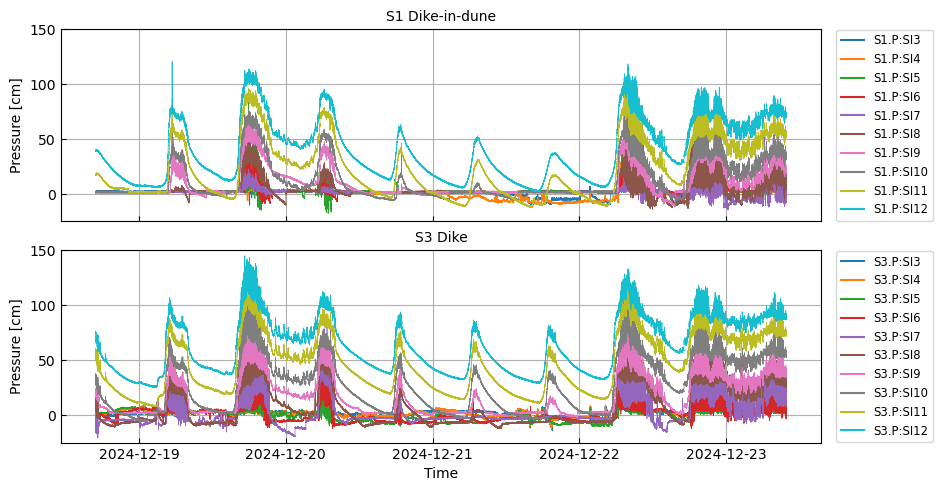

In [ ]:
# Make plot -------------------------------------------------------------------
sections = [1, 3]   # S1, S3 and S4
plot_sensors = {1: range(3, 13), 3: range(3, 13)}  # sensor indices for each section
titles = ['S1 Dike-in-dune', 'S3 Dike']

fig, axes = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True)

for ax, s, title in zip(axes, sections, titles):
    # Plot only the specified sensors for each section
    for n in plot_sensors[s]:
        ax.plot(t[::5], p[s-1, n-1, ::5], linewidth=0.5)  # n-1 for 0-based indexing
    for n in plot_sensors[s]:
        ax.plot(t[1], np.nan, label=f'S{s}.P:SI{n}', linewidth=1.5)  # Make legend entry with thicker line. (plot line is thick because of quick variations)

    ax.set_ylabel('Pressure [cm]')
    ax.set_title(f'{title}',fontsize=10)
    ax.grid(True)
    ax.set_ylim([-25, 150])
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    # Shrink axis to make space for legend
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    # Place legend outside, aligned with the axes (not figure)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize='small', borderaxespad=0, frameon=True)

axes[-1].set_xlabel('Time')
plt.tight_layout(pad=-0.4)
fig.savefig('Plot Kellers storm1_en_2.png', bbox_inches='tight', dpi=450) # PNG

plt.show()

In [95]:
fig.savefig('Plot Kellers storm1_en_2.png', bbox_inches='tight', dpi=450)

In [10]:
# print the font sizes used in the plot
for ax in axes:
    print("Title font size:", ax.title.get_fontsize())
    print("X label font size:", ax.xaxis.label.get_fontsize())
    print("Y label font size:", ax.yaxis.label.get_fontsize())

    xticklabels = ax.get_xticklabels()
    yticklabels = ax.get_yticklabels()
    if xticklabels:
        print("X tick label font size:", xticklabels[0].get_fontsize())
    if yticklabels:
        print("Y tick label font size:", yticklabels[0].get_fontsize())
    legend = ax.get_legend()
    if legend is not None:
        # Legend title font size
        if legend.get_title() is not None:
            print("Legend title font size:", legend.get_title().get_fontsize())
        # First legend item font size
        legend_texts = legend.get_texts()
        if legend_texts:
            print("First legend item font size:", legend_texts[0].get_fontsize())

Title font size: 12.0
X label font size: 10.0
Y label font size: 10.0
Y tick label font size: 10.0
Legend title font size: 10.0
First legend item font size: 8.33
Title font size: 12.0
X label font size: 10.0
Y label font size: 10.0
X tick label font size: 10.0
Y tick label font size: 10.0
Legend title font size: 10.0
First legend item font size: 8.33


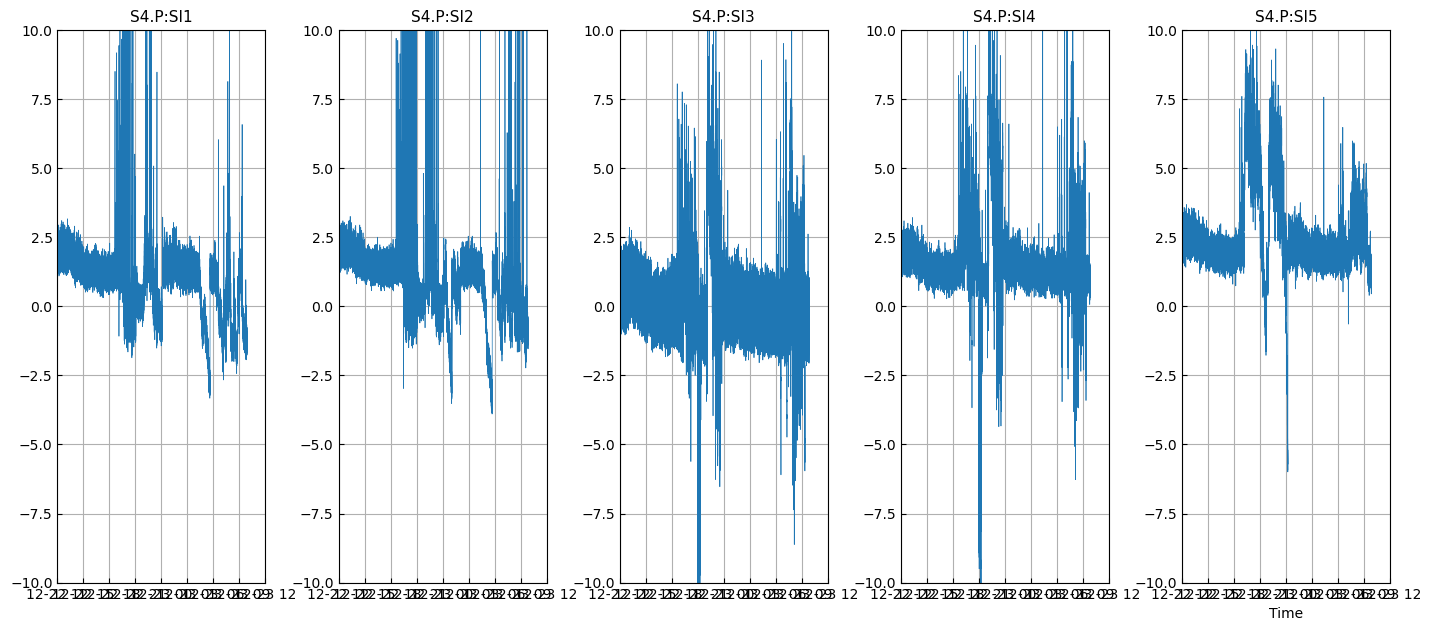

In [43]:
# Make plot -------------------------------------------------------------------
i_storm = 2 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 4
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharex=True)

for i in range(0,5):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5], p[s-1, i, ::5], linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+1}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 10])
    ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout(pad=-0.4)
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

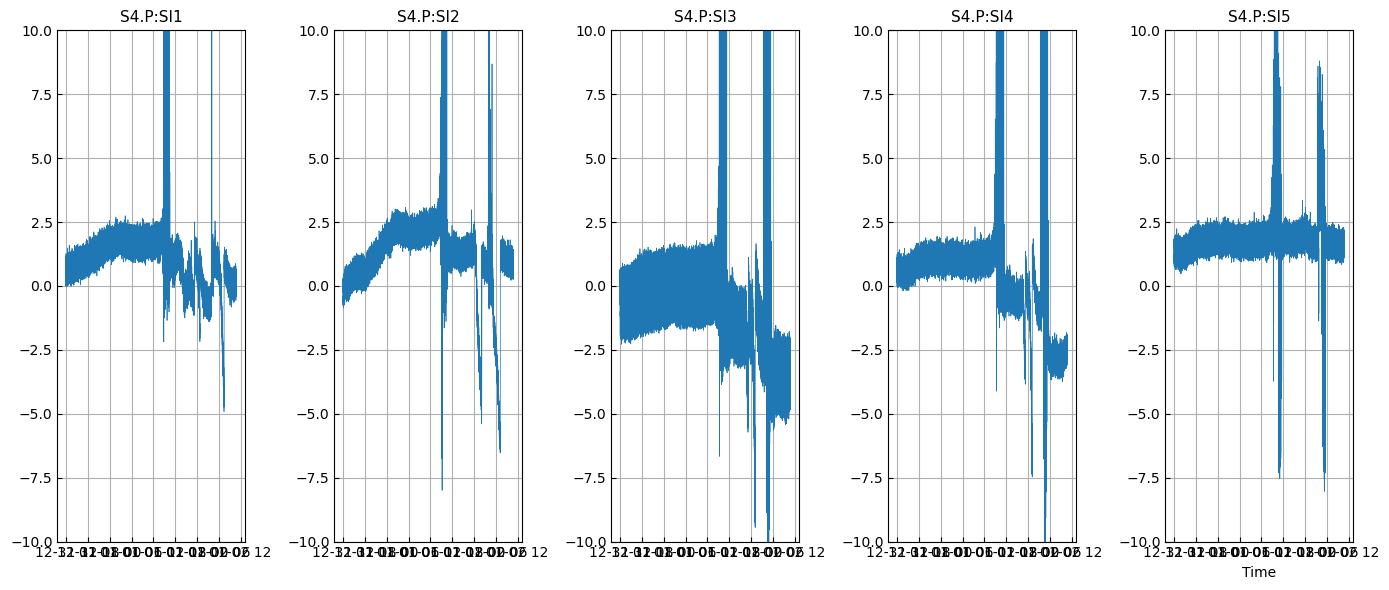

In [44]:
# Make plot -------------------------------------------------------------------
i_storm = 4 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 4
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharex=True)

for i in range(0,5):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5], p[s-1, i, ::5], linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+1}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 10])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

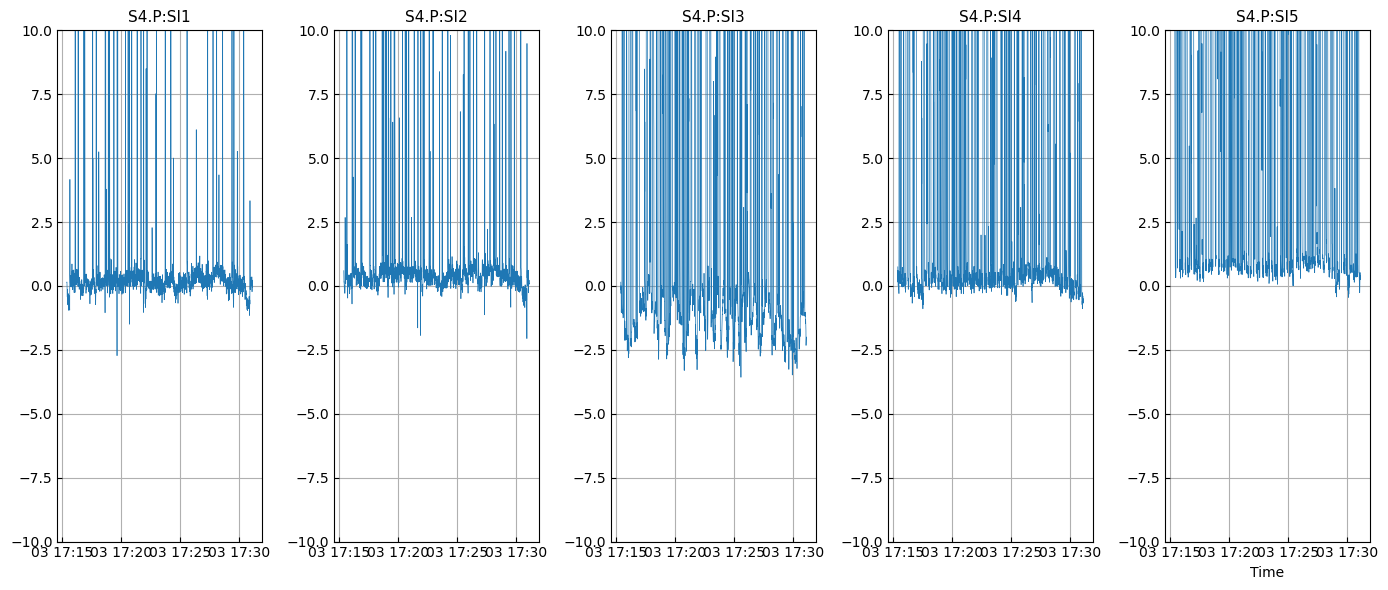

In [72]:
# Make plot -------------------------------------------------------------------
i_storm = 6 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 4
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharex=True)

for i in range(0,5):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5].values, p[s-1, i, ::5].values, linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+1}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 10])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

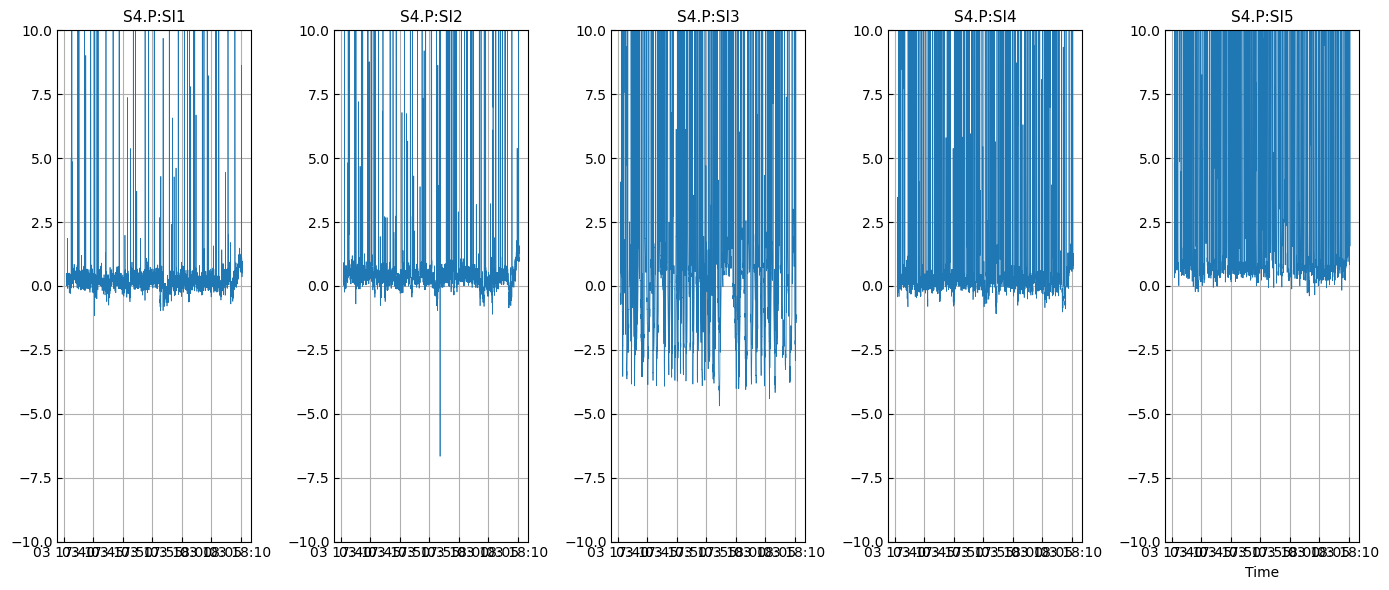

In [46]:
# Make plot -------------------------------------------------------------------
i_storm = 7 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 4
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharex=True)

for i in range(0,5):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5], p[s-1, i, ::5], linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+1}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 10])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

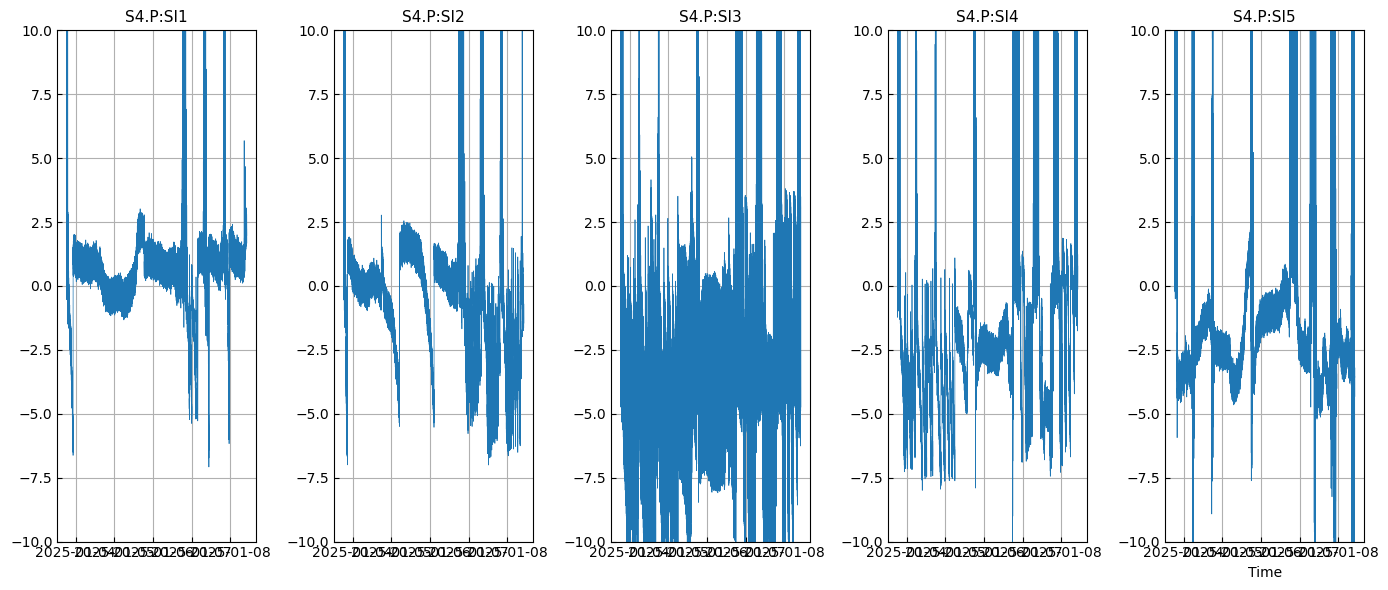

In [57]:
# Make plot -------------------------------------------------------------------
i_storm = 8 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 4
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharex=True)

for i in range(0,5):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5], p[s-1, i, ::5], linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+1}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 10])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

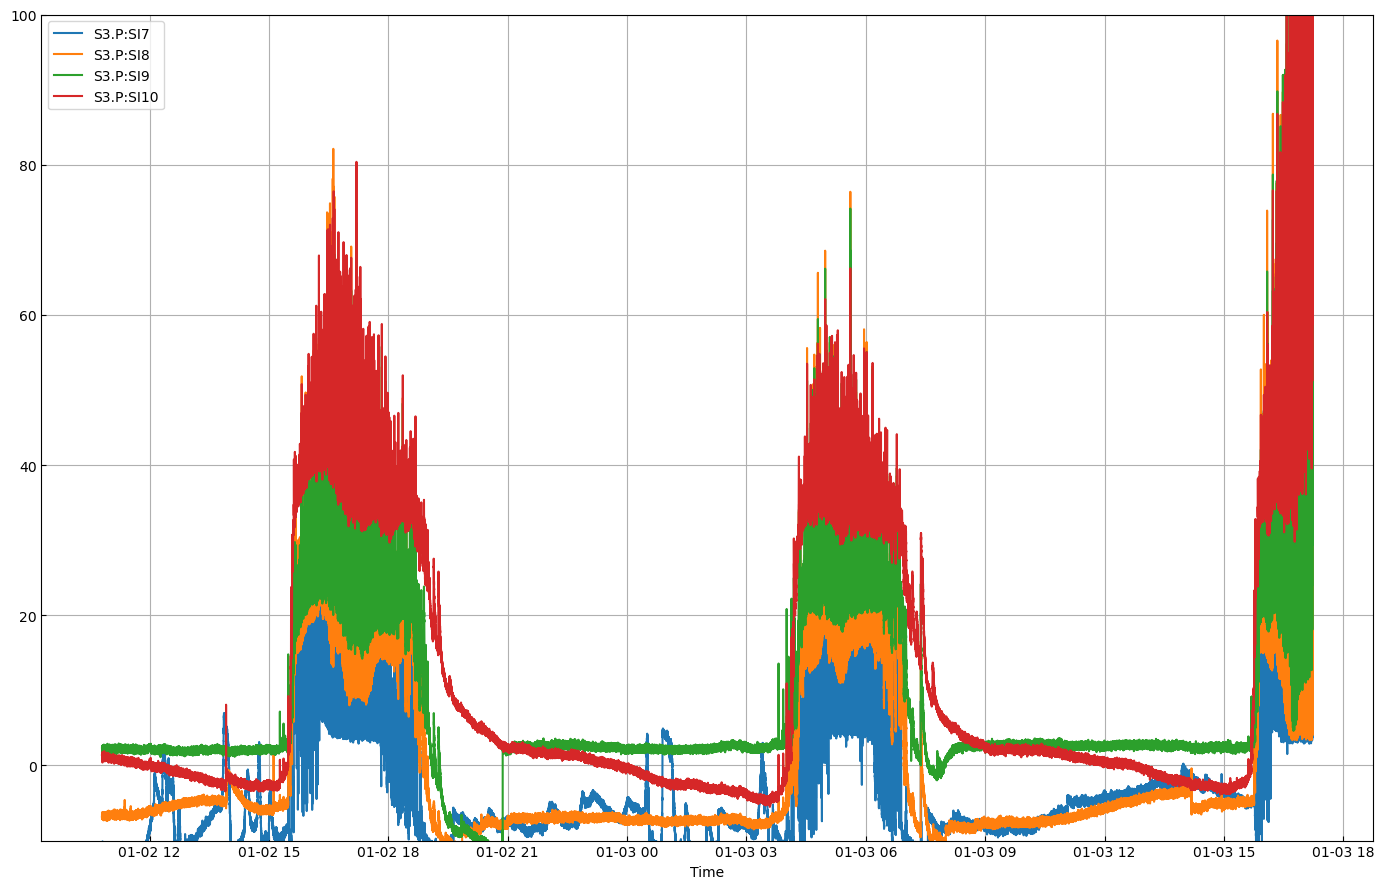

In [83]:
# Make plot -------------------------------------------------------------------
i_storm = 5 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 3

fig, axes = plt.subplots(1, 1, figsize=(14, 9), sharex=True)
ax = axes

for i in range(6, 10):
    # Plot only the specified sensors for each section
    ax.plot(t[::5].values, p[s-1, i, ::5].values,label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.grid(True)
    ax.set_ylim([-10, 100])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()

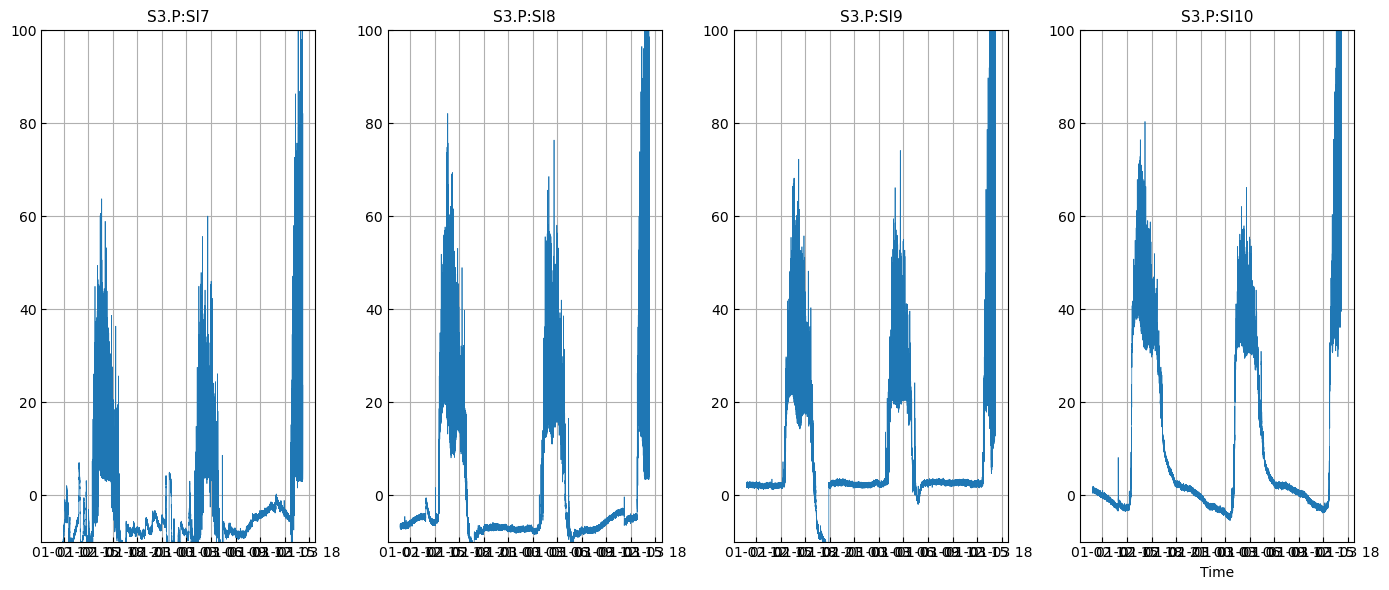

In [86]:
# Make plot -------------------------------------------------------------------
i_storm = 5 #in [2, 4, 6, 7, 8]:
nc_in = get_nc_P_SI(i_storm)
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

s = 3
plot_sensors = {1: range(3, 4), 4: range(1, 6)}  # sensor indices for each section
title = ['S4']

fig, axes = plt.subplots(1, 4, figsize=(14, 6), sharex=True)

for i in range(0,4):
    # Plot only the specified sensors for each section
    ax = axes[i]
    ax.plot(t[::5], p[s-1, i+6, ::5], linewidth=0.5, label=f'S{s}.P:SI{i+1}')  # n-1 for 0-based indexing

    ax.set_title(f'S{s}.P:SI{i+7}',fontsize=11)
    ax.grid(True)
    ax.set_ylim([-10, 100])
    # ax.set_xlim(pd.to_datetime('2024-12-22 12:00'), pd.to_datetime('2024-12-23 12:00'))
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
axes[-1].set_xlabel('Time')
plt.tight_layout()
#fig.savefig('Plot Kellers storm1.pdf', bbox_inches='tight')           # PDF
plt.show()